In [1]:
# Install Ubunut 17.04

# FCServer Install
# git clone https://github.com/scanlime/fadecandy.git
# cd server; make submodules; make
# sudo ./fcserver

# Copy Python library
# cp fadecandy/examples/python/opc.py git/rizhom/notebooks/

In [1]:
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

import opc
import time
import numpy as np

import colorsys

In [2]:
numLEDs = 512
client = opc.Client('localhost:7890')
client.set_interpolation(False)

True

In [31]:
on_length = 5
off_length = 15
speed = -3

on = (140, 140, 140)
off = (0, 0, 0)

values = np.array(([on]*on_length + [off]*off_length) * 21)[:512,:]

while True:
    t = ((speed*time.time() % 60) / 60.0) * numLEDs
    
    pixels = np.roll(values, int(t), axis=0)
    client.put_pixels(pixels)    

KeyboardInterrupt: 

In [9]:
pixels = [ (0,0,0) ] * numLEDs
pixels[0] = (255,255,255)
client.put_pixels(pixels)

True

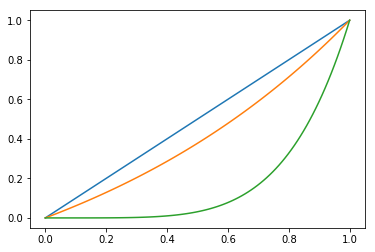

In [23]:
from matplotlib import pyplot as plt

x = np.linspace(0, 1, 100)
plt.plot(x, x)
plt.plot(x, (np.exp(x) - 1) / (np.exp(1) - 1))
plt.plot(x, x**5)
None

### Mapping Chase pixel

In [ ]:
brightness = 30
delay_time = 0.05

i = 0
while True:
    pixels = [ (0,0,0) ] * numLEDs
    pixels[i] = (brightness,brightness,brightness)
    client.put_pixels(pixels)
    
    
    time.sleep(delay_time)
    
    i += 1
    if i >= numLEDs:
        i = 0

### Chase test

In [ ]:
brightness = 255
speed = 10
length = 20

r, g, b = np.random.rand(1)[0], np.random.rand(1)[0], np.random.rand(1)[0]
while True:
    pos = ((speed*time.time() % 60) / 60.0) * numLEDs
    i = int(pos)
    I = pos - int(pos)
    pixels = [ (0,0,0) ] * numLEDs
    pixels[i] = (I*r*brightness, 
                 I*g*brightness, 
                 I*b*brightness)
    for l in range(length):
        pixels[i - l] = (r*brightness, 
                         g*brightness, 
                         b*brightness)

        pixels[int(np.clip(i-length, 0, 59))] = ((1-I)*r*brightness, 
                                                 (1-I)*g*brightness, 
                                                 (1-I)*b*brightness)
    #pixels[int(np.clip(i-2, 0, 59))] = ((I/4)*brightness, (I/4)*brightness, 0)
    client.put_pixels(pixels)

In [28]:
brightness = 150
while True:
	for i in range(numLEDs - 2):
		pixels = [ (0,0,0) ] * numLEDs
		pixels[i] = (brightness, 0, 0)
		pixels[i+1] = (brightness, brightness/2, 0)
		pixels[i+2] = (brightness, brightness, 0)
		client.put_pixels(pixels)
		time.sleep(0.05)

KeyboardInterrupt: 

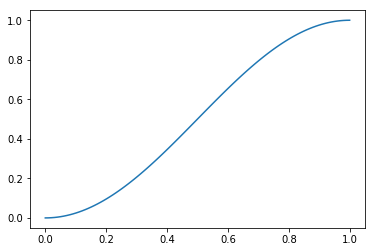

In [47]:
def cos_(x):
    """Maps 0..1 to 0..1 with cos() non-linearity."""
    return (1+np.cos((np.clip(x, 0, 1)-1)*np.pi))/2
x = np.linspace(0, 1, 100)
plt.plot(x, cos_(x))

In [26]:
def hue_to_strip(hue, saturation, brightness):
    color = [([v*255 for v in colorsys.hsv_to_rgb(hue / 360.0, saturation / 255.0, brightness / 255.0)])] * numLEDs
    client.put_pixels(color)

In [33]:
np.tile([1, 2, 3], 2).reshape(-1, 3)

array([[1, 2, 3],
       [1, 2, 3]])

### HUE interface

In [25]:
interact(hue_to_strip, hue=widgets.IntSlider(min=0,max=360,step=1,value=0), 
            saturation=widgets.IntSlider(min=0,max=255,step=1,value=0), 
            brightness=widgets.IntSlider(min=0,max=255,step=1,value=155))

interactive(children=(IntSlider(value=0, description='hue', max=360), IntSlider(value=0, description='saturati…

<function __main__.hue_to_strip(hue, saturation, brightness)>

### Color test

In [5]:
brightness = 255
black = [ (0,0,0) ] * numLEDs
white = [ (brightness,brightness,brightness) ] * numLEDs

# Fade to white
client.put_pixels(black)
client.put_pixels(black)
time.sleep(0.5)
client.put_pixels(white)

interact(f, brightness=widgets.IntSlider(min=0,max=255,step=1,value=0))

NameError: name 'f' is not defined

### Animate audio clip

In [83]:
def audio_to_strip(volume, pitch, delta_t=0.1):
    for idx, vol in enumerate(volume):
        color = [v*255 for v in colorsys.hsv_to_rgb(pitch[idx], 1, volume[idx])] * numLEDs
        client.put_pixels(color)
        time.sleep(delta_t)

In [82]:
[v*255 for v in colorsys.hsv_to_rgb(1, 1, 1)]

[255, 0.0, 0.0]